In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import cmocean
import gcm_filters
import matplotlib
from skimage.measure import find_contours
from scipy.interpolate import splprep, splev
from shapely.geometry import Polygon, Point
import numpy as np
import xgcm
import os

## Load data

In [2]:
# Define local data path
datapath = "path/to/data/"

if not os.path.exists(datapath+"contours/"):
    os.makedirs(datapath+"contours/")



# Set initial parameters for the contour and filter configurations
contour_name, n, contour_foverH, contour_depth = "lofoten", 0, 4.4e-8, 3114
#contour_name, n, contour_foverH, contour_depth  = "norwegian", 0, 4.4e-8, 3500

# Choose contour type: f/H or depth
Ctype = "h"

# Select filter scale and name for smoothing operations
filter_scale, filter_name = 50e3, "50km"

# Define the dataset file path (remote or local)
filename = "https://thredds.met.no/thredds/dodsC/romshindcast/lofoten800_2017/ocean_avg_0122.nc4"

# Open dataset using xarray
ds = xr.open_dataset(filename)

In [3]:
# Rename dataset dimensions for compatibility with xgcm
ds = ds.rename({'eta_u': 'eta_rho', 'xi_v': 'xi_rho', 'xi_psi': 'xi_u', 'eta_psi': 'eta_v'})

# Define chunk sizes for parallel processing
xchunk, ychunk, tchunk = -1, -1, -1
chunks = {"ocean_time": tchunk, "xi_rho": xchunk, "xi_u": xchunk, "eta_rho": ychunk, "eta_v": ychunk}
ds = ds.chunk(chunks)

# Define coordinates for xgcm grid
coords = {'X': {'center': 'xi_rho', 'inner': 'xi_u'}, 'Y': {'center': 'eta_rho', 'inner': 'eta_v'}, 'Z': {'center': 's_rho', 'outer': 's_w'}}
grid = xgcm.Grid(ds, coords=coords, periodic=[])

# Calculate vertical coordinate positions at rho and w points
Zo_rho = (ds.hc * ds.s_rho + ds.Cs_r * ds.h) / (ds.hc + ds.h)
z_rho = Zo_rho * (ds.zeta + ds.h) + ds.zeta
Zo_w = (ds.hc * ds.s_w + ds.Cs_w * ds.h) / (ds.hc + ds.h)
z_w = Zo_w * (ds.zeta + ds.h) + ds.zeta

# Add calculated z-coordinates to the dataset
ds.coords['z_w'] = z_w.where(ds.mask_rho, 0).transpose('ocean_time', 's_w', 'eta_rho', 'xi_rho')
ds.coords['z_rho'] = z_rho.where(ds.mask_rho, 0).transpose('ocean_time', 's_rho', 'eta_rho', 'xi_rho')

# Interpolate grid metrics to different points
ds['pm_v'] = grid.interp(ds.pm, 'Y')
ds['pn_u'] = grid.interp(ds.pn, 'X')
ds['pm_u'] = grid.interp(ds.pm, 'X')
ds['pn_v'] = grid.interp(ds.pn, 'Y')
ds['pm_psi'] = grid.interp(grid.interp(ds.pm, 'Y'), 'X')  # Interpolated to psi points
ds['pn_psi'] = grid.interp(grid.interp(ds.pn, 'X'), 'Y')  # Interpolated to psi points

# Calculate grid spacings and areas at different points
ds['dx'] = 1/ds.pm
ds['dx_u'] = 1/ds.pm_u
ds['dx_v'] = 1/ds.pm_v
ds['dx_psi'] = 1/ds.pm_psi
ds['dy'] = 1/ds.pn
ds['dy_u'] = 1/ds.pn_u
ds['dy_v'] = 1/ds.pn_v
ds['dy_psi'] = 1/ds.pn_psi

# Calculate vertical grid spacing differences
ds['dz'] = grid.diff(ds.z_w, 'Z', boundary='fill')
ds['dz_w'] = grid.diff(ds.z_rho, 'Z', boundary='fill')
ds['dz_u'] = grid.interp(ds.dz, 'X')
ds['dz_w_u'] = grid.interp(ds.dz_w, 'X')
ds['dz_v'] = grid.interp(ds.dz, 'Y')
ds['dz_w_v'] = grid.interp(ds.dz_w, 'Y')

# Calculate grid cell areas
ds['dA'] = ds.dx * ds.dy

# Define metrics for the xgcm grid object
metrics = {
    ('X',): ['dx', 'dx_u', 'dx_v', 'dx_psi'],  # X distances
    ('Y',): ['dy', 'dy_u', 'dy_v', 'dy_psi'],  # Y distances
    ('Z',): ['dz', 'dz_u', 'dz_v', 'dz_w', 'dz_w_u', 'dz_w_v'],  # Z distances
    ('X', 'Y'): ['dA']  # Areas
}

# Re-create the grid object with the new metrics
grid = xgcm.Grid(ds, coords=coords, metrics=metrics, periodic=[])


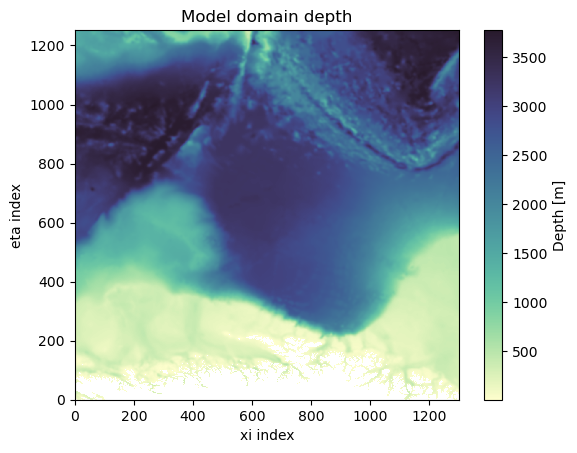

In [4]:
# Plot depth data on map
fig, ax = plt.subplots()
cm = ax.pcolormesh(ds.h.where(ds.mask_rho), cmap=cmocean.cm.deep)
ax.set_xlabel("xi index")
ax.set_ylabel("eta index")
fig.colorbar(cm, label="Depth [m]")
ax.set_title("Model domain depth")
ax.set_aspect("equal")

## Filter depth data

Filter data using GCM_filters

Text(0.5, 1.0, 'Filter used for smoothing bathymetry')

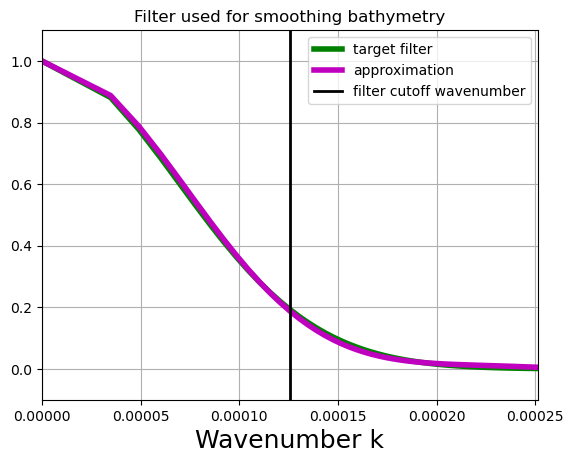

In [5]:
# Extract grid info for filtering
wet_mask_t = ds.mask_rho
dxT = 1/ds.pn
dyT = 1/ds.pm
area = dxT * dyT

# Determine grid metrics for U and V points
dxCu = dxT  # dx at U points
dyCu = dyT  # dy at U points
dxCv = dxT  # dx at V points
dyCv = dyT  # dy at V points

# Find minimum and maximum grid spacing
dx_min = min(dxT.where(wet_mask_t).min(), dyT.where(wet_mask_t).min()).values
dx_max = max(dxT.max(), dyT.max(), dxCu.max(), dyCu.max(), dxCv.max(), dyCv.max()).values

# Initialize diffusivity fields for the filter
kappa_iso = xr.ones_like(dxT)
kappa_aniso = xr.zeros_like(dyT)
kappa_w = xr.ones_like(dxCu)
kappa_s = xr.ones_like(dxCu)

# Define grid variables for GCM filter
grid_vars_diff = {
    'wet_mask': wet_mask_t, 
    'dxw': dxCu, 'dyw': dyCu,
    'dxs': dxCv, 'dys': dyCv,
    'area': area, 'kappa_w': kappa_w, 'kappa_s': kappa_s
}

# Initialize the GCM filter with Gaussian shape
filter = gcm_filters.Filter(
    filter_scale=filter_scale,
    dx_min=dx_min,
    filter_shape=gcm_filters.FilterShape.GAUSSIAN,
    grid_type=gcm_filters.GridType.IRREGULAR_WITH_LAND,
    grid_vars=grid_vars_diff
)

# %%
# Plot the filter shape
fig, ax = plt.subplots()
filter.plot_shape(ax)
ax.set_title("Filter used for smoothing bathymetry")

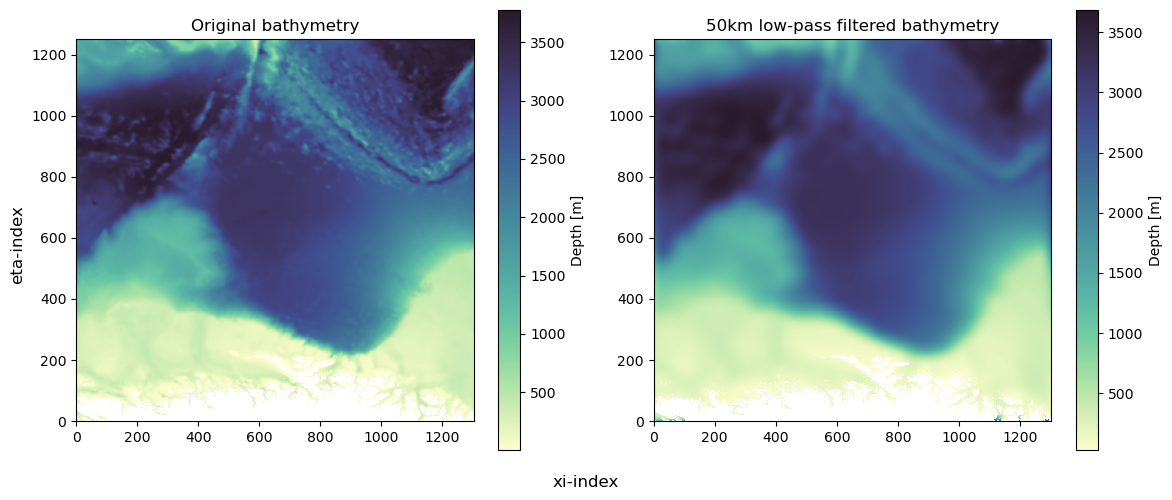

In [6]:
# Apply the filter to the bathymetry data
h_filtered = filter.apply(ds.h, dims=("eta_rho", "xi_rho"))

# Plot original and filtered bathymetry side-by-side
fig, [ax1, ax2] = plt.subplots(ncols=2, figsize=(12, 5))
cm1 = ax1.pcolormesh(ds.h.where(ds.mask_rho), cmap=cmocean.cm.deep)
cm2 = ax2.pcolormesh(h_filtered.where(ds.mask_rho), cmap=cmocean.cm.deep)
ax1.set_title("Original bathymetry")
ax2.set_title(f"{filter_name} low-pass filtered bathymetry")
fig.colorbar(cm1, ax=ax1, label="Depth [m]")
fig.colorbar(cm2, ax=ax2, label="Depth [m]")
fig.supxlabel("xi-index")
fig.supylabel("eta-index")
ax1.set_aspect("equal")
ax2.set_aspect("equal")

fig.tight_layout()

## Find contours

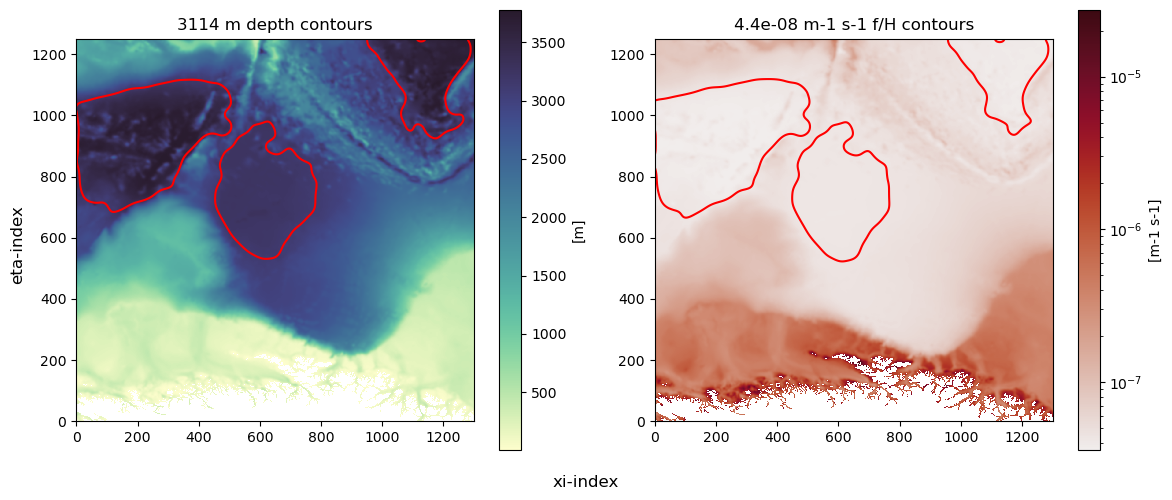

In [7]:
# Calculate f/H and apply mask
foverH = ds.f / ds.h.where(ds.mask_rho)
h_filtered = h_filtered.where(ds.mask_rho)
foverH_filtered = ds.f / h_filtered

# Plot filtered contours
fig, [ax1, ax2] = plt.subplots(ncols=2, figsize=(12, 5))
cb1 = ax1.pcolormesh(h_filtered.xi_rho, h_filtered.eta_rho, ds.h.where(ds.mask_rho), cmap=cmocean.cm.deep)
ax1.contour(h_filtered.xi_rho, h_filtered.eta_rho, h_filtered, levels=[contour_depth], colors="red")
fig.colorbar(cb1, ax=ax1, label="[m]")
ax1.set_aspect("equal")

cb2 = ax2.pcolormesh(foverH_filtered.xi_rho, foverH_filtered.eta_rho, foverH, norm=matplotlib.colors.LogNorm(), cmap=cmocean.cm.amp)
ax2.contour(foverH_filtered.xi_rho, foverH_filtered.eta_rho, foverH_filtered, levels=[contour_foverH], colors="red")
fig.colorbar(cb2, ax=ax2, label="[m-1 s-1]")
ax2.set_aspect("equal")

ax1.set_title(f"{contour_depth} m depth contours")
ax2.set_title(f"{contour_foverH} m-1 s-1 f/H contours")

fig.supxlabel("xi-index")
fig.supylabel("eta-index")

fig.tight_layout()

In [8]:
# Find contours based on selected type
if Ctype == "foverh":
    contours = find_contours(foverH_filtered.values, level=contour_foverH)
elif Ctype == "h":
    contours = find_contours(h_filtered.values, level=contour_depth)
contour = contours[n]

# Reverse second dimension to match coordinate system
contour = contour[:, ::-1]

# Convert the contour coordinates to a closed polygon
polygon = Polygon(contour)

# Create a mesh grid for coordinates
Xi, Eta = np.meshgrid(ds.xi_rho, ds.eta_rho)

# Function to create a mask from the polygon
def create_mask(Xi, Eta, polygon):
    mask = np.zeros(Xi.shape, dtype=bool)
    for i in range(Xi.shape[0]):
        for j in range(Xi.shape[1]):
            mask[i, j] = polygon.contains(Point(Xi[i, j], Eta[i, j]))
    return mask

# Apply the mask creation function
mask = create_mask(Xi, Eta, polygon)
mask_da = xr.DataArray(mask, coords=[ds.eta_rho, ds.xi_rho], dims=["eta_rho", "xi_rho"])


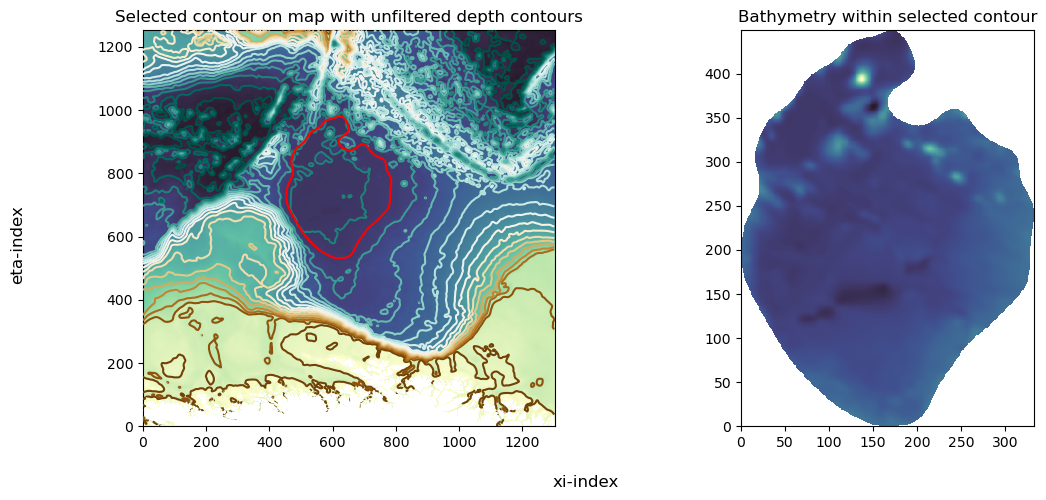

In [9]:
# Extract the bathymetry within the mask
hc = ds.h.where(mask_da, drop=True)

# Plot the mask and extracted bathymetry
fig, [ax1, ax2] = plt.subplots(ncols=2, figsize=(12, 5))
ax1.pcolormesh(ds.h.where(ds.mask_rho), cmap=cmocean.cm.deep)
ax1.contour(ds.xi_rho, ds.eta_rho, ds.h.where(ds.mask_rho), zorder=10, cmap="BrBG", levels=20)
ax1.plot(contour[:, 0], contour[:, 1], color="red", zorder=20)
ax2.pcolormesh(hc, cmap=cmocean.cm.deep)

ax1.set_title("Selected contour on map with unfiltered depth contours")
ax2.set_title("Bathymetry within selected contour")

fig.supxlabel("xi-index")
fig.supylabel("eta-index")

ax1.set_aspect("equal")
ax2.set_aspect("equal")

fig.tight_layout()

In [10]:
# Identify boundary cells for horizontal and vertical edges
mask_left = np.roll(mask, shift=1, axis=1)
mask_right = np.roll(mask, shift=-1, axis=1)
mask_up = np.roll(mask, shift=1, axis=0)
mask_down = np.roll(mask, shift=-1, axis=0)

# Determine boundary masks
horizontal_boundary_mask = (mask & (~mask_left | ~mask_right))
vertical_boundary_mask = (mask & (~mask_up | ~mask_down))

# Select edge lengths
dx_edge = ds['dx']
dy_edge = ds['dy']

# Calculate horizontal and vertical boundary lengths
horizontal_edge_lengths = dx_edge.where(horizontal_boundary_mask, 0)
vertical_edge_lengths = dy_edge.where(vertical_boundary_mask, 0)

# Sum to get total circumference
circumference = (horizontal_edge_lengths.sum() + vertical_edge_lengths.sum()).values
mask_da["L"] = circumference

In [11]:
# Save the mask to file with contour type attributes
if Ctype=="foverh":
    mask_da.attrs["foverh_value"] = contour_foverH
elif Ctype=="h":
    mask_da.attrs["h_value"] = contour_depth
    
mask_da.to_netcdf(f"contours/{contour_name}_{Ctype}_{filter_name}_mask.nc")

In [12]:
# Create tangential vectors along the contour
contourx = contour[:, 0]
contoury = contour[:, 1]
tx = contourx[1:] - contourx[:-1]
ty = contoury[1:] - contoury[:-1]
dist = np.sqrt(tx**2 + ty**2)

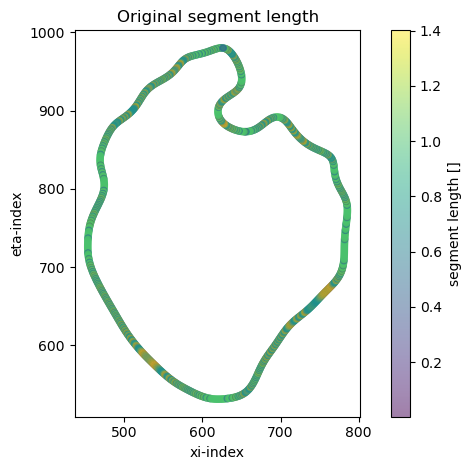

In [13]:
# Plot length of each contour segment
fig, ax = plt.subplots()
x = np.arange(len(dist))
s = ax.scatter(contourx[:-1], contoury[:-1], c=dist, cmap="viridis", alpha=0.5, s=20)
fig.colorbar(s, label="segment length []")
ax.set_xlabel("xi-index")
ax.set_ylabel("eta-index")
ax.set_aspect("equal")

ax.set_title("Original segment length")
fig.tight_layout()

In [14]:
### Adjust contour segments to be of equal length

# Fit spline to contour data
tck, u = splprep([contour[:, 0], contour[:, 1]], s=0.1)

# Evaluate spline on evenly spaced interval
num_points = len(dist)
new_u = np.linspace(0, 1, num_points)
new_points = splev(new_u, tck)

# %%
# Re-calculate tangential vectors 
contourx = new_points[0]
contoury = new_points[1]
tx = contourx[1:] - contourx[:-1]
ty = contoury[1:] - contoury[:-1]
dist = np.sqrt(tx**2 + ty**2)
np.mean(dist)

0.7681596931918198

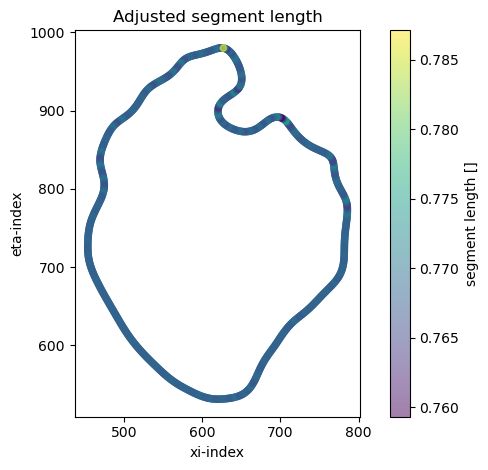

In [15]:
# Plot new tangential vectors
fig, ax = plt.subplots()
x = np.arange(len(dist))
s = ax.scatter(contourx[:-1], contoury[:-1], c=dist, cmap="viridis", alpha=0.5, s=20)
fig.colorbar(s, label="segment length []")
ax.set_xlabel("xi-index")
ax.set_ylabel("eta-index")
ax.set_aspect("equal")

ax.set_title("Adjusted segment length")
fig.tight_layout()

In [16]:
# Normalize tangents and adjust direction based on contour type
if Ctype == "foverh":
    tx = -tx / dist
    ty = -ty / dist
elif Ctype == "h":
    tx = tx / dist
    ty = ty / dist

In [17]:
# Create an xarray dataset for tangential vectors
dsc = xr.Dataset(
    data_vars=dict(
        tx=(["point"], tx),
        ty=(["point"], ty),
    ),
    coords=dict(
        point=np.arange(len(tx)),
        xi_rho=("point", contourx[:-1]),
        eta_rho=("point", contoury[:-1])
    ),
    attrs=dict(description=f"Tangent {contour_name} contour."),
)

# Add contour type attribute
if Ctype == "foverh":
    dsc.attrs["foverh_value"] = contour_foverH
elif Ctype == "h":
    dsc.attrs["h_value"] = contour_depth

In [18]:
# Calculate metric distance using grid spacings
dxc, dyc = ds.dx.interp(xi_rho=dsc.xi_rho, eta_rho=dsc.eta_rho), ds.dy.interp(xi_rho=dsc.xi_rho, eta_rho=dsc.eta_rho)
metricdist = np.sqrt((dist * dxc * dsc.tx)**2 + (dist * dyc * dsc.ty)**2)
dsc["distance"] = ("point", metricdist.values)

# Save the contour dataset to a NetCDF file
dsc.to_netcdf(f"contours/{contour_name}_{Ctype}_{filter_name}_contour.nc")

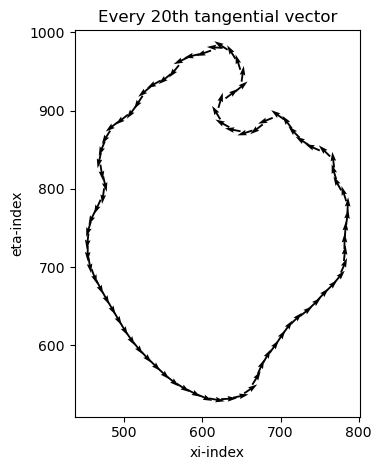

In [19]:
# Visualize direction of tangential vectors
fig, ax = plt.subplots()
dscs = dsc.isel(point=slice(None, None, 20))
ax.quiver(dscs.xi_rho, dscs.eta_rho, dscs.tx, dscs.ty)
ax.set_aspect("equal")
ax.set_xlabel("xi-index")
ax.set_ylabel("eta-index")

ax.set_title("Every 20th tangential vector")
fig.tight_layout()